# Death Records: Demographics, Marital Status, and Age Patterns

This project explores a large U.S. death records dataset alongside its reference tables (race codes, marital status codes) to look for patterns across race, age, and marital status. I clean up messy sentinel values (like the 999 age placeholder), build a series of bar and box plots with matplotlib and seaborn, and compare how marital status distributions shift across different age groups.

## Exploring Race and Resident Status Codes

We can read in the death data set, and the other decoder data sets 

In [1]:
import pandas as pd 

In [2]:
myDF = pd.read_csv('/anvil/projects/tdm/data/death_records/DeathRecords.csv')

In [3]:
race = pd.read_csv('/anvil/projects/tdm/data/death_records/Race.csv')

In [4]:
maritalStatus = pd.read_csv('/anvil/projects/tdm/data/death_records/MaritalStatus.csv')

In [5]:
race

,Code,Description
0,0,Other races
1,1,White
2,2,Black
3,3,American Indian (includes Aleuts and Eskimos)
4,4,Chinese
5,5,Japanese
6,6,Hawaiian (includes Part-Hawaiian)
7,7,Filipino
8,8,Other Asian or Pacific Islander
9,18,Asian Indian


In [6]:
race.head()

,Code,Description
0,0,Other races
1,1,White
2,2,Black
3,3,American Indian (includes Aleuts and Eskimos)
4,4,Chinese


#1.1 - We can learn from the decoder that each race has a specific number representing them. 
0     Other races                                                                                                    
1     White                                                                                                          
2     Black                                                                                                          
3     American Indian (includes Aleuts and Eskimos)                                                                  
4     Chinese                                                                                                        
5     Japanese                                                                                                       
6     Hawaiian (includes Part-Hawaiian)                                                                              
7     Filipino                                                                                                       
8     Other Asian or Pacific Islander                                                                                
18    Asian Indian                                                                                                   
28    Korean                                                                                                         
38    Samoan                                                                                                         
48    Vietnamese                                                                                                     
58    Guamanian                                                                                                      
68    Other Asian or Pacific Islander in areas reporting codes 18-58                                                 
78    Combined other Asian or Pacific Islander, includes codes 18-68 for areas that do not report them separately    

#1.2 - Another helpful decoder would be for resident status. This would be intresting becasue of the way they split it up. For example, does ResidentStatus 1 represent a state? A town? A city?

In [7]:
myDF.head()

,Id,ResidentStatus,Education1989Revision,Education2003Revision,EducationReportingFlag,MonthOfDeath,Sex,AgeType,Age,AgeSubstitutionFlag,...,CauseRecode39,NumberOfEntityAxisConditions,NumberOfRecordAxisConditions,Race,BridgedRaceFlag,RaceImputationFlag,RaceRecode3,RaceRecode5,HispanicOrigin,HispanicOriginRaceRecode
0,1,1,0,2,1,1,M,1,87,0,...,24,1,1,1,0,0,1,1,100,6
1,2,1,0,2,1,1,M,1,58,0,...,21,3,3,1,0,0,1,1,100,6
2,3,1,0,7,1,1,F,1,75,0,...,28,2,2,1,0,0,1,1,100,6
3,4,1,0,6,1,1,M,1,74,0,...,22,3,3,1,0,0,1,1,100,6
4,5,1,0,3,1,1,M,1,64,0,...,21,1,1,1,0,0,1,1,100,6


This is the kind of graph we can make without matplotlib 

<Axes: xlabel='Race'>

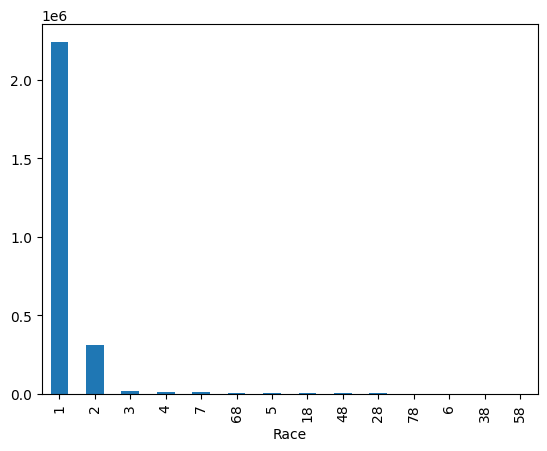

In [8]:
myDF['Race'].value_counts().plot(kind='bar')

In [9]:
import matplotlib.pyplot as plt 

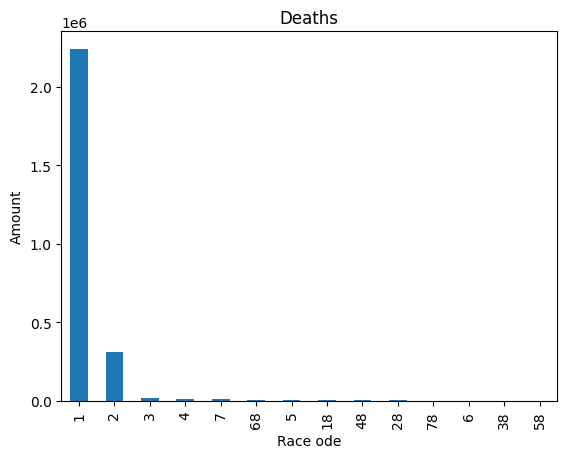

In [10]:
myDF['Race'].value_counts().plot(kind='bar')
plt.title("Deaths")
plt.xlabel("Race ode")
plt.ylabel("Amount")
plt.show()

#1.3 - We can look at which race has the smallest entries by using value counts. Using the decoder we can see that code 58 (Guamanian) had the least amount of entries. 

In [11]:
race

,Code,Description
0,0,Other races
1,1,White
2,2,Black
3,3,American Indian (includes Aleuts and Eskimos)
4,4,Chinese
5,5,Japanese
6,6,Hawaiian (includes Part-Hawaiian)
7,7,Filipino
8,8,Other Asian or Pacific Islander
9,18,Asian Indian


In [12]:
myDF['Race'].value_counts(sort=True, ascending=False)

Race
1     2241510
2      309504
3       18031
4       13297
7       11074
68       8737
5        8159
18       6778
48       4913
28       4711
78       2818
6         700
38        623
58        316
Name: count, dtype: int64

## Visualizing Death Counts by Race 

We can filter the whole data set so we can only see the codes that are not 1 (so basically every race except for 1 which is white)

In [13]:
filtered1 = myDF[myDF['Race'] != 1]

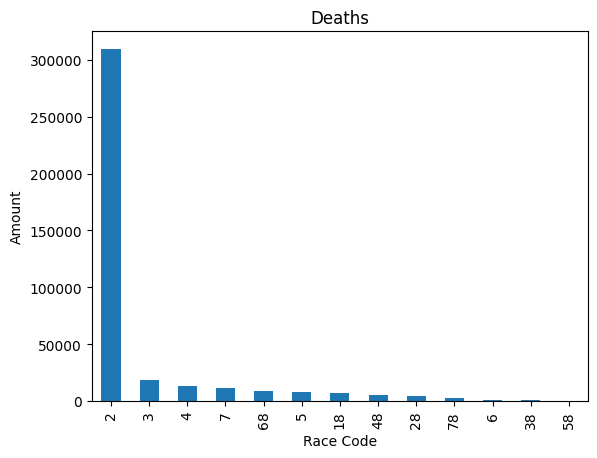

In [14]:
filtered1['Race'].value_counts().plot(kind='bar')
plt.title("Deaths")
plt.xlabel("Race Code")
plt.ylabel("Amount")
plt.show()

We can try switching things up to make the graphs more readable by also taking out the race code 2 (black)

In [15]:
filtered2 = myDF[(myDF['Race'] != 1) & (myDF['Race'] != 2)]

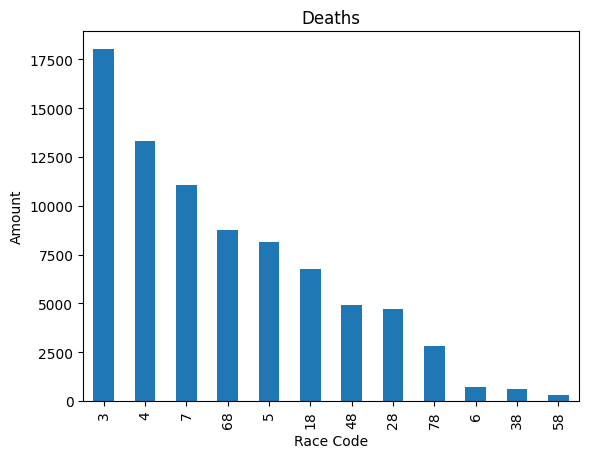

In [16]:
filtered2['Race'].value_counts().plot(kind='bar')
plt.title("Deaths")
plt.xlabel("Race Code")
plt.ylabel("Amount")
plt.show()

Instead of a bar graph, we can make a line graph instead. Seeing the line and bar charts together, I would use the bar chart because it is easier to read and understand 

In [17]:
filtered3 = myDF[(myDF['Race'] != 1) & (myDF['Race'] != 2)]

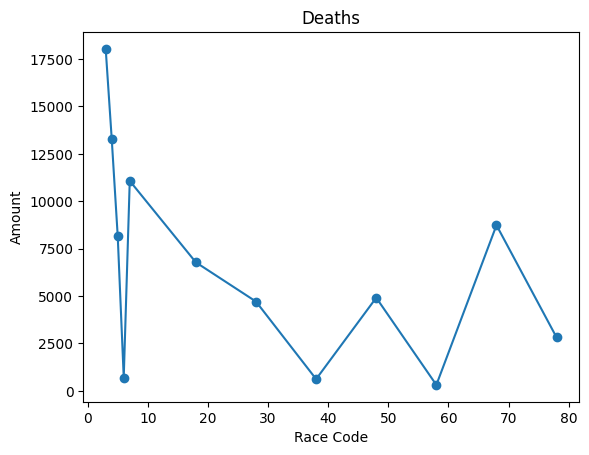

In [18]:
filtered3['Race'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Deaths")
plt.xlabel("Race Code")
plt.ylabel("Amount")
plt.show()

#2.1 - I made my plots unique by taking away the data points that we too high which made the graph hard to read. By taking away the two bigger numbers, the graph becomes clearer. 

#2.2 - I made the plots more readable for people who dont have as much in depth knowledge by adding a title, x-axis title, and y-axis title. 

#2.3 - I ended up cutting out the race code of 1 (white) and 2 (black). I did this so the graph was more readable becasue both of them had a much larger number than the rest, so it was hard to read the graph with 2 big outliers. 

## Age Distribution by Marital Status

We can look at the marital status decoder for the data set 

In [25]:
maritalStatus

,Code,Description
0,S,"Never married, single"
1,M,Married
2,W,Widowed
3,D,Divorced
4,U,Marital Status unknown


In [28]:
myDF['MaritalStatus'].head()

0    M
1    D
2    W
3    D
4    D
Name: MaritalStatus, dtype: object

#3.1 - We can import the seaborn library to do more higher level plotting 

In [30]:
import seaborn as sns

Since the 999 is making the graph hard to read, we can exlude them from the data to make the graph more readable 

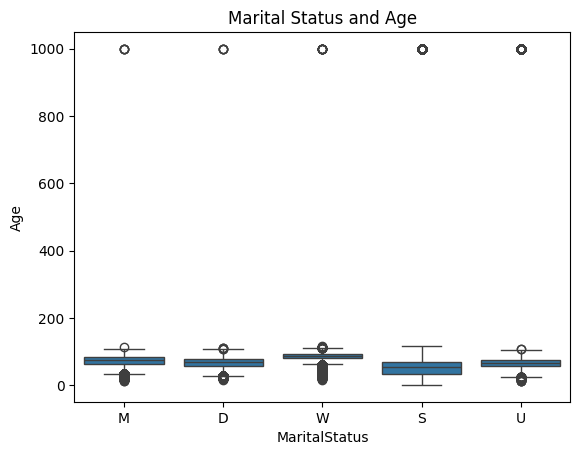

In [32]:
sns.boxplot(x='MaritalStatus', y='Age', data=myDF)
plt.title("Marital Status and Age") 
plt.show()

In [35]:
cleanDF = myDF[myDF['Age'] != 999]

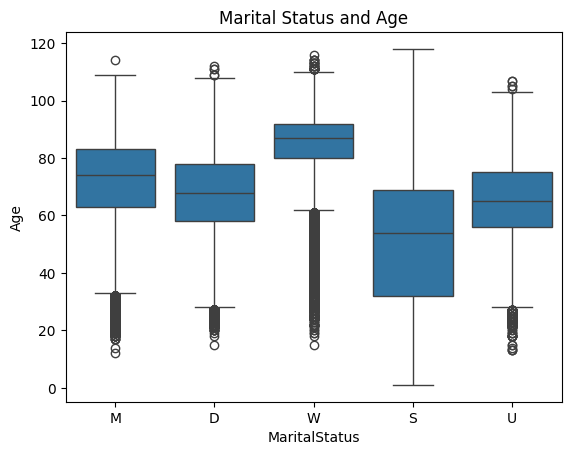

In [36]:
sns.boxplot(x='MaritalStatus', y='Age', data=cleanDF)
plt.title("Marital Status and Age") 
plt.show()

#3.2 - comparing these two graphs, the one with out the 999 is much easier to read and understand 

#3.3 - For each category of marital status, the graph allows us to see the age range for each category with outliars being the dots above or below the horizontal lines. 

## Comparing Marital Status Across Age Groups

#4.1 - we can explain the box plot above for marries vs widowed people by saying that the mean of the widowed group is higher than the married group and there are a lot more outliars in the widowed group than the married. And the range of the ages is much smaller in the widowed group. 

We can take a better look the marital status by looking at the value counts 

In [37]:
cleanDF['MaritalStatus'].value_counts()

MaritalStatus
M    980012
W    898430
D    400955
S    332792
U     18411
Name: count, dtype: int64

In [40]:
subset = cleanDF[cleanDF['MaritalStatus'].isin(['D', 'S'])]

In [48]:
newSubset = subset[subset['Age'] == 60]

In [49]:
my_counts = newSubset['MaritalStatus'].value_counts()

In [50]:
my_counts

MaritalStatus
D    10134
S     6166
Name: count, dtype: int64

In [61]:
subset1 = cleanDF[cleanDF['MaritalStatus'].isin(['M', 'W'])]

#4.2 - We can make a barplot for different categories 

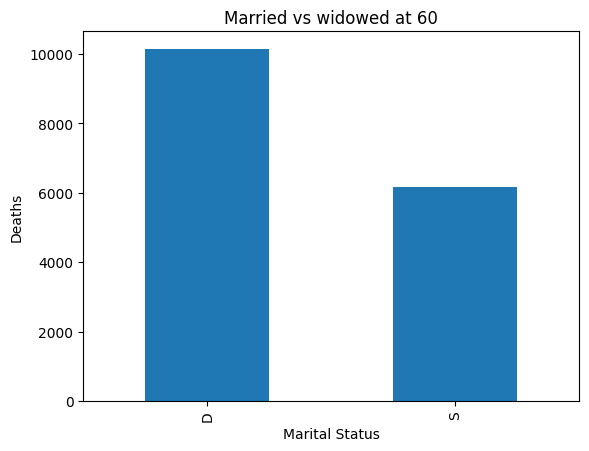

In [62]:
my_counts.plot(kind = 'bar')
plt.title('Married vs widowed at 60')
plt.xlabel('Marital Status')
plt.ylabel('Deaths')
plt.show()

In [65]:
subset80 = subset[subset['Age'] == 80]
count80 = subset80['MaritalStatus'].value_counts()

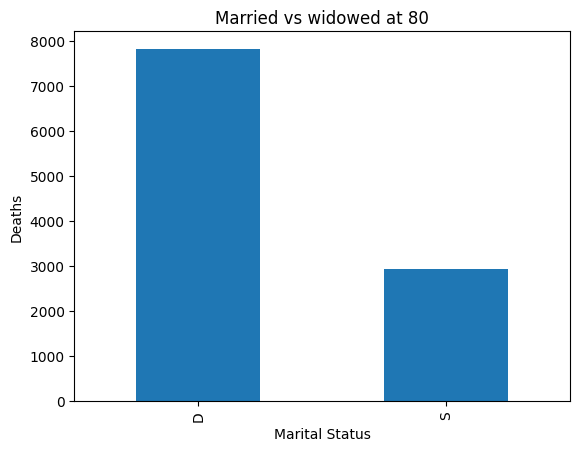

In [66]:
count80.plot(kind = 'bar')
plt.title('Married vs widowed at 80')
plt.xlabel('Marital Status')
plt.ylabel('Deaths')
plt.show()

In [51]:
import matplotlib.pyplot as plt

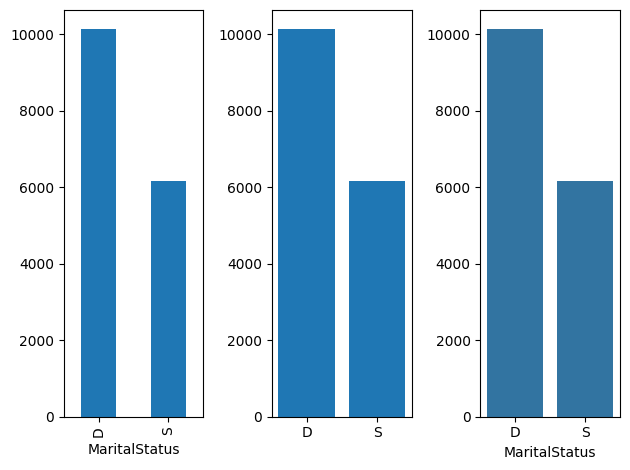

In [52]:
my_counts = newSubset['MaritalStatus'].value_counts()# prepare the data and plotting space
fig, axes = plt.subplots(nrows=1, ncols=3)
labels = my_counts.index
counts = my_counts.values

# pandas
my_counts.plot(kind='bar', ax=axes[0])

# matplotlib
axes[1].bar(labels, counts)

# seaborn
sns.barplot(x=labels, y=counts, ax=axes[2])

# display the plots
plt.tight_layout()
plt.show()

#4.3 - the differences I see in pandas, matplotlib, and seaborn and very small. Pandas has a lighter shade of blue and smaller bars. matplot has thicker bars and the x-axis titles and right side up and not titled, and seaborn has a darker blue and also right side up x-axis titles  

## Age Trends at Death: 60, 70, and 80 Year-Olds

#5.1 - We can filter the data set even more for ages 60, 70 and 80

In [54]:
first_count = cleanDF[cleanDF['Age'] == 60]['MaritalStatus'].value_counts().sort_index()
second_count = cleanDF[cleanDF['Age'] == 70]['MaritalStatus'].value_counts().sort_index()
third_count = cleanDF[cleanDF['Age'] == 80]['MaritalStatus'].value_counts().sort_index()

this is the plot for the 60 year olds 

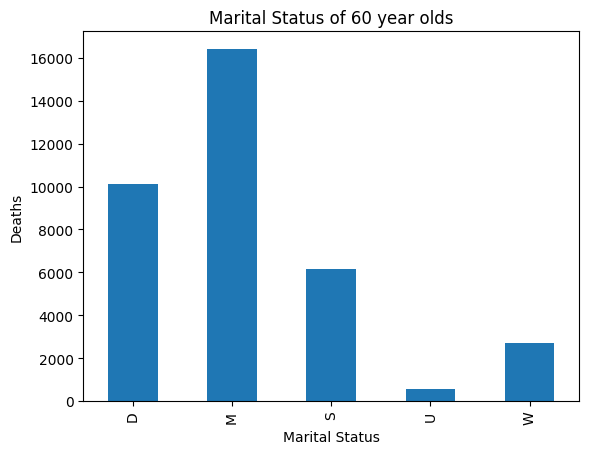

In [56]:
first_count.plot(kind = 'bar')
plt.title('Marital Status of 60 year olds')
plt.xlabel('Marital Status')
plt.ylabel('Deaths')
plt.show()

plot for 70 year olds

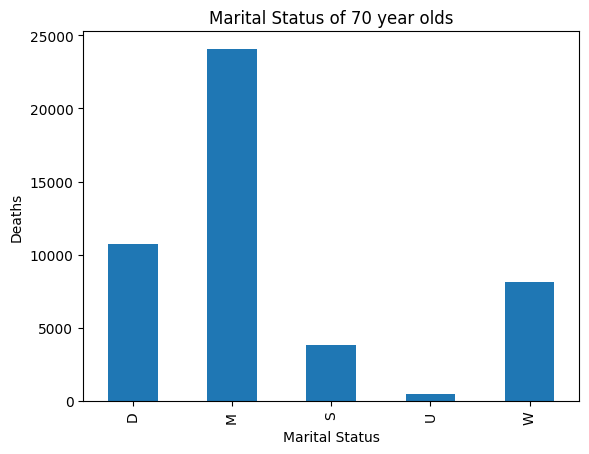

In [57]:
second_count.plot(kind = 'bar')
plt.title('Marital Status of 70 year olds')
plt.xlabel('Marital Status')
plt.ylabel('Deaths')
plt.show()

plot for 80 year olds 

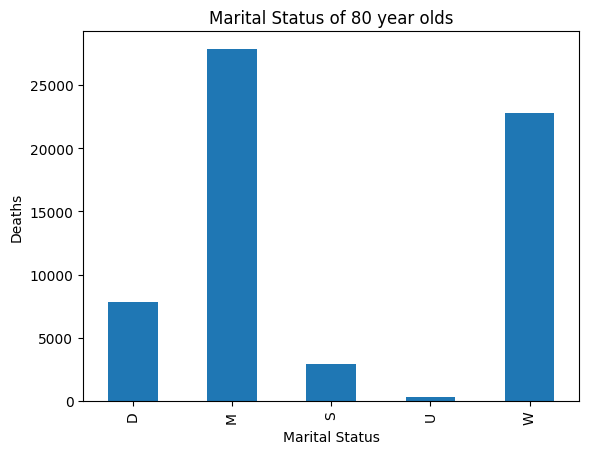

In [58]:
third_count.plot(kind = 'bar')
plt.title('Marital Status of 80 year olds')
plt.xlabel('Marital Status')
plt.ylabel('Deaths')
plt.show()

#5.2 - after looking at all the graphs for the 60, 70, and 80 year olds we can see that the status shifts the older they get. As they get older, the bigger the widowed bar gets, and the smaller the divored bar gets. 

#5.3 - Something I was curious about was a histogram about the age people are when they die. 

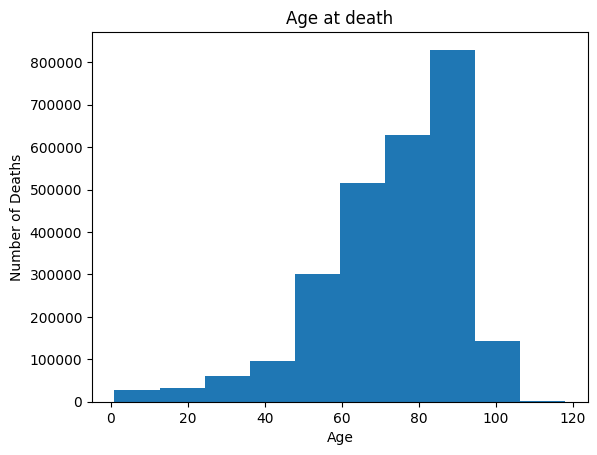

In [60]:
cleanDF['Age'].plot(kind = 'hist')
plt.title('Age at death')
plt.xlabel('Age')
plt.ylabel('Number of Deaths')
plt.show()